In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression

# **Data Loading & Time Alignment**

In [2]:
def process_mpp_meteo():
    print("--- Starting data processing (process_mpp_meteo) ---")

    # 1. Data loading
    print("Loading parquet files...")
    mpp_0 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/M0/MPP_interp.parquet')
    mpp_12 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/P12/MPP_interp.parquet')
    cams = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/CAMS.parquet')
    meteo = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/METEO-2025-09-22_18_36_58--2025-11-11_22_01_04_calibrado23.4864.parquet')
    print("Files loaded.")

    # 2. Basic preprocessing
    mpp_0.set_index('time', inplace=True)
    mpp_12.set_index('time', inplace=True)

    # Round METEO to seconds to facilitate merging
    meteo.index = meteo.index.round('s')
    meteo.index.name = 'time'
    meteo = meteo.rename(columns={'Power' : 'local_irradiance_wm2'})

    # Manual warnings about known gaps
    print('\nMETEO: From 2025-10-05 22:00:56 jumps directly to 2025-10-05 23:00:01. (Data missing in that interval)')
    print('METEO: From 2025-10-06 22:00:59 jumps directly to 2025-10-06 23:00:00. (Data missing in that interval)')

    cams.set_index('time', inplace=True)
    cams.rename(columns={'irradiancia_30_grados':'irradiance_30_degrees'}, inplace=True)
    print('CAMS: Missing data for 11/11.')

    cams_30 = cams.loc[:, ['hour_fraction', 'irradiance_30_degrees']]
    cams_30 = cams_30.rename(columns={'irradiance_30_degrees': 'irradiance_30_degrees_wm2'})

    # 3. Aligning METEO with CAMS (Backward)
    print("\nAligning METEO with CAMS...")
    cams_30 = cams_30.sort_index()
    # Changed to direction='backward'
    df_meteo_cams = pd.merge_asof(meteo['local_irradiance_wm2'], cams_30, on='time', direction='backward', tolerance=pd.Timedelta('60s'))

    # Remove nights (daytime hours: 06:00:00 - 22:00:00)
    df_meteo_cams_clean = df_meteo_cams.copy()
    df_meteo_cams_clean = df_meteo_cams_clean[(df_meteo_cams_clean['time'].dt.time >= pd.to_datetime('06:00:00').time()) & (df_meteo_cams_clean['time'].dt.time <= pd.to_datetime('22:00:00').time())]

    print(f"NaN in df_meteo_cams_clean (before imputation):\n{df_meteo_cams_clean.isnull().sum()}")
    print('CAMS has missing values (NaN) due to the cutoff time difference (00:59:30 in CAMS vs 21:59:57 in METEO on 11/11)')
    null_percentage = df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams_clean) * 100
    print(f"Global null percentage: {null_percentage:.2f}%")
    print(f'NaNs correspond to  ∼{round(null_percentage)}%  of total data')

    # 4. Imputation of CAMS irradiance using METEO
    print("\nImputation of missing CAMS values:")
    print("\nImputing missing CAMS irradiance with METEO data (temporarily)...")
    df_meteo_cams_clean['irradiance_30_is_imputed'] = (df_meteo_cams_clean['irradiance_30_degrees_wm2'].isnull() == True).astype(int)
    df_meteo_cams_clean['irradiance_30_degrees_wm2'] = df_meteo_cams_clean['irradiance_30_degrees_wm2'].fillna(df_meteo_cams_clean['local_irradiance_wm2'])

    print(f"NaN percentage after irradiance imputation: {df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams) * 100:.2f}%")

    # 5. Imputation of 'hour_fraction'
    # A reference day (2025-09-27) is used to fill gaps of hour_fraction in other days
    print("\nImputing missing CAMS 'hour_fraction' using pattern day 2025-09-27 (example)...")
    df_meteo_cams_clean.set_index('time', inplace=True)
    hour_fraction_input = df_meteo_cams_clean[df_meteo_cams_clean.index.date == pd.to_datetime('2025-09-27').date()]['hour_fraction']
    df_meteo_cams_nan = df_meteo_cams_clean[df_meteo_cams_clean['hour_fraction'].isnull()]['hour_fraction']

    df_meteo_cams_nan = df_meteo_cams_nan.to_frame()
    df_meteo_cams_nan.reset_index(inplace=True)
    df_meteo_cams_nan = df_meteo_cams_nan.drop('time', axis=1)
    df_meteo_cams_nan = df_meteo_cams_nan.fillna(0)

    hour_fraction_input = hour_fraction_input.to_frame()
    hour_fraction_input.reset_index(inplace=True)
    hour_fraction_input = hour_fraction_input.drop('time', axis=1)

    df_meteo_cams_nan = df_meteo_cams_nan.sort_index()
    hour_fraction_input = hour_fraction_input.sort_index()

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(df_meteo_cams_nan, hour_fraction_input, left_index=True, right_index=True, direction='backward', tolerance=2)
    df_input = df_align_0.copy()['hour_fraction_y']
    df_meteo_cams_clean.loc[df_meteo_cams_clean['hour_fraction'].isnull(), 'hour_fraction'] = df_input.values

    print(f'Final NaNs after imputing hour_fraction: {df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams) * 100:.4f}%')

    # 6. Alignment of MPP with METEO & CAMS (06:00:00 - 22:00:00)
    print("\nAligning MPP data with CAMS dataset...")
    # Remove nights in MPP
    mpp_clean_0 = mpp_0.copy()
    mpp_clean_0 = mpp_clean_0[(mpp_clean_0.index.time >= pd.to_datetime('06:00:00').time()) & (mpp_clean_0.index.time <= pd.to_datetime('22:00:00').time())]
    mpp_clean_12 = mpp_12.copy()
    mpp_clean_12 = mpp_clean_12[(mpp_clean_12.index.time >= pd.to_datetime('06:00:00').time()) & (mpp_clean_12.index.time <= pd.to_datetime('22:00:00').time())]

    # Alignment MPP with CAMS
    df_meteo_cams_clean = df_meteo_cams_clean.sort_index()

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(mpp_clean_0, df_meteo_cams_clean, on='time', direction='backward', tolerance=pd.Timedelta('4s'))
    df_align_12 = pd.merge_asof(mpp_clean_12, df_meteo_cams_clean, on='time', direction='backward', tolerance=pd.Timedelta('4s'))

    # 7. Post-alignment cleaning
    print('\nPost-alignment cleaning:')
    print('Removing MPP rows prior to the first valid irradiance data point from CAMS + METEO to ensure proper alignment...')
    before_dropna = len(df_align_0)
    df_align_0 = df_align_0.dropna()
    print(f"M0 rows cleaned after dropna: {before_dropna - len(df_align_0)}")
    df_align_0 = df_align_0.reset_index()

    before_dropna = len(df_align_12)
    df_align_12 = df_align_12.dropna()
    print(f"P12 rows cleaned after dropna: {before_dropna - len(df_align_12)}")
    df_align_12 = df_align_12.reset_index()

    # 8. Adding extra environmental variables (METEO)
    print("\nAdding METEO environmental variables (Temp, Humidity)...")

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(df_align_0, meteo[['DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity' ]], on='time', direction='backward', tolerance=pd.Timedelta('4s'))
    df_align_12 = pd.merge_asof(df_align_12, meteo[['DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity' ]], on='time', direction='backward', tolerance=pd.Timedelta('4s'))

    print(f'NaN found in final M0: {df_align_0.isnull().sum().sum()}')
    print(f'inf found in final M0: {(len(df_align_0) - np.isfinite(df_align_0).sum()).sum()}')
    print(f'NaN found in final P12: {df_align_12.isnull().sum().sum()}')
    print(f'inf found in final P12: {(len(df_align_12) - np.isfinite(df_align_12).sum()).sum()}')

    # 9. Vertical merge and unit conversion
    print("\nJoining M0 and P12 datasets and converting units...")
    df_align_0.insert(loc=1, column='cell_id', value=0) # Label M0
    df_align_12.insert(loc=1, column='cell_id', value=1) # Label P12
    df_align = pd.concat([df_align_0, df_align_12], axis=0, ignore_index=True)

    # Conversion W/m2 to mW/cm2 (Factor: * 0.1)
    df_align['local_irradiance_wm2'] = df_align['local_irradiance_wm2'] * 1000 / 10000
    df_align = df_align.rename(columns={'local_irradiance_wm2' : 'local_irradiance_mwcm2'})

    df_align['irradiance_30_degrees_wm2'] = df_align['irradiance_30_degrees_wm2'] * 1000 / 10000
    df_align = df_align.rename(columns={'irradiance_30_degrees_wm2' : 'irradiance_30_degrees_mwcm2'})
    df_align = df_align.rename(columns={'power' : 'power_cell_mwcm2'})
    df_align['irradiance_30_is_imputed'] = df_align['irradiance_30_is_imputed'].astype(int)

    if df_align.index.name == None:
        df_align.set_index('time', inplace=True)

    print(f"--- Process finished. Final dimensions: {df_align.shape} ---")
    return df_align

In [3]:
df_align = process_mpp_meteo()

--- Starting data processing (process_mpp_meteo) ---
Loading parquet files...
Files loaded.

METEO: From 2025-10-05 22:00:56 jumps directly to 2025-10-05 23:00:01. (Data missing in that interval)
METEO: From 2025-10-06 22:00:59 jumps directly to 2025-10-06 23:00:00. (Data missing in that interval)
CAMS: Missing data for 11/11.

Aligning METEO with CAMS...
NaN in df_meteo_cams_clean (before imputation):
time                             0
local_irradiance_wm2             0
hour_fraction                18230
irradiance_30_degrees_wm2    18230
dtype: int64
CAMS has missing values (NaN) due to the cutoff time difference (00:59:30 in CAMS vs 21:59:57 in METEO on 11/11)
Global null percentage: 3.98%
NaNs correspond to  ∼4%  of total data

Imputation of missing CAMS values:

Imputing missing CAMS irradiance with METEO data (temporarily)...
NaN percentage after irradiance imputation: 1.33%

Imputing missing CAMS 'hour_fraction' using pattern day 2025-09-27 (example)...
Final NaNs after imputing

In [4]:
df_align

,index,cell_id,power_cell_mwcm2,local_irradiance_mwcm2,hour_fraction,irradiance_30_degrees_mwcm2,irradiance_30_is_imputed,DeviceTemp,t_chamber,AmbientTemp,Humidity
time,,,,,,,,,,,
2025-09-22 18:51:22,864,0,1.151306,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4
2025-09-22 18:51:23,865,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4
2025-09-22 18:51:24,866,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4
2025-09-22 18:51:25,867,0,1.156216,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4
2025-09-22 18:51:26,868,0,1.147543,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 21:59:56,2891485,1,0.000000,0.000000,21.991667,0.000000,1,13.19,16.42,12.2,70.0
2025-11-11 21:59:57,2891486,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0
2025-11-11 21:59:58,2891487,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0


**Plotting power vs irradiance per day**

In [5]:
def plot_power_irradiance(df):
    if df.index.name == None:
        df.set_index('time', inplace=True)
        df.index = pd.to_datetime(df.index)

    # List of unique days
    day = np.unique(df.index.date)

    sns.set_style('white')

    for k in range(len(day)):
        # Create subplots: 1 row, 2 columns
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Iterate over cells (IDs)
        for i, ax1 in zip([0, 1], axes):
            mask_id = df.loc[(df['cell_id'] == i) & (df.index.date == day[k])]

            # Create first axis for CAMS irradiance
            sns.lineplot(
                x = mask_id.index,
                y = mask_id['irradiance_30_degrees_mwcm2'].values,
                linewidth = 2.8,
                linestyle = '--',
                color = 'darkorange',
                errorbar = None,
                label = 'CAMS Irradiance (mW/cm²)',
                ax = ax1
            )

            sns.lineplot(
                x = mask_id.index,
                y = mask_id['local_irradiance_mwcm2'].values,
                linestyle = '--',
                color = 'blue',
                errorbar = None,
                label = 'Local Irradiance (mW/cm²)',
                alpha=0.4,
                ax = ax1
            )

            ax1.set_xlabel('Time of day')
            ax1.set_ylabel('Irradiance (mW/cm²)', color='darkorange')
            ax1.tick_params(axis='y', labelcolor='darkorange')

            # Create second axis for produced power
            ax2 = ax1.twinx()
            sns.lineplot(
                x = mask_id.index,
                y = mask_id['power_cell_mwcm2'].values,
                color = 'forestgreen',
                label='Power Produced (mW/cm²)',
                alpha=0.4,
                ax=ax2
            )

            ax2.set_ylabel('Power Produced (mW/cm²)', color='forestgreen')
            ax2.tick_params(axis='y', labelcolor='forestgreen')

            # Plot title
            ax1.set_title(f'Irradiance and Power Produced {day[k]} ({k}) ID:{i}')

            # Time axis
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax1.set_xlim(mask_id.loc[mask_id.index.date == day[k]].index[0], mask_id.loc[mask_id.index.date == day[k]].index[-1])

            # Grid
            ax1.grid(True, linestyle='--', alpha=0.7)

            # Legend
            ax1.legend(loc='upper left')
            ax2.legend(loc='upper right')

        plt.tight_layout()
        plt.show()

    return

In [6]:
def analyze_top4_by_cell(df, cell_id):
    # 1. Ensure the index is datetime
    if df.index.name == None:
        if 'time' in df.columns:
            df.set_index('time', inplace=True)
    df.index = pd.to_datetime(df.index)

    # 2. Validate and isolate the requested cell data
    if cell_id not in [0, 1]:
        print('[ERROR] cell not found. Use 0 for M0 or 1 for P12.')
        return

    cell_name = 'M0' if cell_id == 0 else 'P12'
    df_cell = df[df['cell_id'] == cell_id].copy()

    # 3. Efficiency logic only for this cell
    daily_received = df_cell['irradiance_30_degrees_mwcm2'].resample('D').sum() / (3600 * 100)
    daily_produced = df_cell['power_cell_mwcm2'].resample('D').sum() / (3600 * 100)

    # Align and calculate efficiency
    aligned_produced, aligned_received = daily_produced.align(daily_received, join='inner')
    eff = (aligned_produced / aligned_received) * 100

    # Clean infinities/NaNs and sort in descending order
    eff = eff.replace([np.inf, -np.inf], np.nan).dropna()
    eff_best = eff.sort_values(ascending=False)

    # Extract the top 4 dates
    top_4_dates = eff_best.index[:4].date
    top_4_effs = eff_best.values[:4]

    # 4. Create the 2x2 matrix
    sns.set_style('white')
    fig, axs = plt.subplots(2, 2, figsize=(16, 14))

    # Iterate over the 4 subplots in the matrix
    for k, (ax, target_date) in enumerate(zip(axs.ravel(), top_4_dates)):

        # Filter data only for the target day and between 06:00 and 22:00
        day_data = df_cell[df_cell.index.date == target_date]
        day_data = day_data.between_time('06:00', '22:00').copy()

        if day_data.empty:
            continue

        ax1 = ax

        # Axis 1: CAMS Irradiance
        sns.lineplot(
            x = day_data.index,
            y = day_data['irradiance_30_degrees_mwcm2'].values,
            linewidth = 2.8,
            linestyle = '--',
            color = 'darkorange',
            errorbar = None,
            label = 'CAMS Irradiance (mW/cm²)',
            ax = ax1
        )

        # Axis 1: Local Irradiance
        sns.lineplot(
            x = day_data.index,
            y = day_data['local_irradiance_mwcm2'].values,
            linestyle = '--',
            color = 'blue',
            errorbar = None,
            label = 'Local Irradiance (mW/cm²)',
            alpha = 0.4,
            ax = ax1
        )

        ax1.set_xlabel('Time of day', fontsize=14)
        ax1.set_ylabel('Irradiance (mW/cm²)', color='darkorange', fontsize=14)
        ax1.tick_params(axis='y', labelcolor='darkorange', labelsize=14)

        # Axis 2: Produced power
        ax2 = ax1.twinx()
        sns.lineplot(
            x = day_data.index,
            y = day_data['power_cell_mwcm2'].values,
            color = 'forestgreen',
            linewidth = 2,
            label = 'Produced Power (mW/cm²)',
            alpha = 0.4, # Kept with transparency as in your first code
            ax = ax2
        )

        ax2.set_ylabel('Produced Power (mW/cm²)', color='forestgreen', fontsize=14)
        ax2.tick_params(axis='y', labelcolor='forestgreen', labelsize=14)

        # Individual title
        ax1.set_title(f'TOP #{k+1}: {target_date} - Efficiency: {top_4_effs[k]:.3f}%', fontsize=16, fontweight='bold')

        # X-axis format (Hours:Minutes)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.set_xlim([day_data.index[0], day_data.index[-1]])
        ax1.tick_params(axis='x', labelsize=14)

        # Grid
        ax1.grid(True, linestyle='--', alpha=0.6)

        # Legends
        ax1.legend(loc='upper left', fontsize=12)
        ax2.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.show()

# **Data Cleaning: Artifact Cleaning (Quality Control)**

In [8]:
def data_clean(df_align):
    print("--- Starting data cleaning (data_clean) ---")
    df_clean = df_align.copy()

    # 1. Cleaning POWER (Power Artifacts)
    mask_power_art = (((df_clean['power_cell_mwcm2'] != 0) & (df_clean['local_irradiance_mwcm2'] < 0.5)) | (df_clean['power_cell_mwcm2'] < 0))
    df_clean['power_art'] = mask_power_art.astype(int)
    n_power_art = mask_power_art.sum()
    print(f"\nPower Artifacts detected: {n_power_art}")
    if n_power_art > 0:
        print("Setting 'power_cell_mwcm2' to 0 in those records...")
    df_clean.loc[mask_power_art, 'power_cell_mwcm2'] = 0

    # 2. Cleaning LOCAL IRRADIANCE (Irradiance Artifacts)
    mask_irr_art = ((df_clean['local_irradiance_mwcm2'] != 0) & (df_clean['power_cell_mwcm2'] == 0) & (df_clean['irradiance_30_degrees_mwcm2'] == 0))
    df_clean['local_irradiance_art'] = mask_irr_art.astype(int)
    n_irr_art = mask_irr_art.sum()
    print(f"\nLocal Irradiance Artifacts detected: {n_irr_art}")
    if n_irr_art > 0:
        print("Setting 'local_irradiance_mwcm2' to 0 in those records...")
    df_clean.loc[mask_irr_art, 'local_irradiance_mwcm2'] = 0


    # 3. Cleaning OVER-IRRADIANCE (Physical Limits > 100)
    # Recortamos (clip) la irradiancia local para que no supere 100 mW/cm2
    mask_over_local = df_clean['local_irradiance_mwcm2'] > 100.0
    n_over_local = mask_over_local.sum()
    print(f"\nOver-Irradiance (Local > 100) detected: {n_over_local}")
    if n_over_local > 0:
        print("Clipping 'local_irradiance_mwcm2' maximum values to 100.0...")
        df_clean.loc[mask_over_local, 'local_irradiance_mwcm2'] = 100.0

    # Hacemos lo mismo para la irradiancia CAMS (por si acaso también tiene picos ruidosos)
    mask_over_cams = df_clean['irradiance_30_degrees_mwcm2'] > 100.0
    n_over_cams = mask_over_cams.sum()
    print(f"Over-Irradiance (CAMS > 100) detected: {n_over_cams}")
    if n_over_cams > 0:
        print("Clipping 'irradiance_30_degrees_mwcm2' maximum values to 100.0...")
        df_clean.loc[mask_over_cams, 'irradiance_30_degrees_mwcm2'] = 100.0

    print("\n--- Cleaning finished ---")
    return df_clean

In [9]:
df_clean = data_clean(df_align)

--- Starting data cleaning (data_clean) ---

Power Artifacts detected: 46266
Setting 'power_cell_mwcm2' to 0 in those records...

Local Irradiance Artifacts detected: 92472
Setting 'local_irradiance_mwcm2' to 0 in those records...

Over-Irradiance (Local > 100) detected: 23894
Clipping 'local_irradiance_mwcm2' maximum values to 100.0...
Over-Irradiance (CAMS > 100) detected: 0

--- Cleaning finished ---


In [10]:
df_clean

,index,cell_id,power_cell_mwcm2,local_irradiance_mwcm2,hour_fraction,irradiance_30_degrees_mwcm2,irradiance_30_is_imputed,DeviceTemp,t_chamber,AmbientTemp,Humidity,power_art,local_irradiance_art
time,,,,,,,,,,,,,
2025-09-22 18:51:22,864,0,1.151306,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:23,865,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:24,866,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:25,867,0,1.156216,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4,0,0
2025-09-22 18:51:26,868,0,1.147543,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 21:59:56,2891485,1,0.000000,0.000000,21.991667,0.000000,1,13.19,16.42,12.2,70.0,0,0
2025-11-11 21:59:57,2891486,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0,0,0
2025-11-11 21:59:58,2891487,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0,0,0


# **CAMS Data Imputation using Machine Learning (Linear Regression)**

In [12]:
df_imp = df_clean.copy()

In [13]:
df_imp

,index,cell_id,power_cell_mwcm2,local_irradiance_mwcm2,hour_fraction,irradiance_30_degrees_mwcm2,irradiance_30_is_imputed,DeviceTemp,t_chamber,AmbientTemp,Humidity,power_art,local_irradiance_art
time,,,,,,,,,,,,,
2025-09-22 18:51:22,864,0,1.151306,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:23,865,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:24,866,0,1.156250,15.782845,18.841667,21.441425,0,27.28,29.58,22.3,35.4,0,0
2025-09-22 18:51:25,867,0,1.156216,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4,0,0
2025-09-22 18:51:26,868,0,1.147543,15.735872,18.841667,21.441425,0,27.26,29.57,22.3,35.4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 21:59:56,2891485,1,0.000000,0.000000,21.991667,0.000000,1,13.19,16.42,12.2,70.0,0,0
2025-11-11 21:59:57,2891486,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0,0,0
2025-11-11 21:59:58,2891487,1,0.000000,0.000000,21.991667,0.000000,1,13.22,16.42,12.2,70.0,0,0


In [16]:
def make_mi_scores(X, y, discrete_features):
      mi_scores = mutual_info_regression(X, y, discrete_features = discrete_features)
      mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
      mi_scores = mi_scores.sort_values(ascending=False)
      return mi_scores

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)

    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    plt.show()

def impute_cams_lr(df=df_imp, smooth_window='30min', train_day_split=19, cross_val=True):

    print("--- Starting Linear Regression imputation (impute_cams_lr) ---")
    df = df.copy()
    features=['hour_sin', 'hour_cos', 't_chamber', 'smooth_local_irradiance_mwcm2', 'Humidity', 'day_sin', 'day_cos']

    # 1. Feature Engineering
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_fraction'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_fraction'] / 24)

    df['day_sin'] = np.sin(2 * np.pi * df.index.day / 30)
    df['day_cos'] = np.cos(2 * np.pi * df.index.day / 30)


    df.sort_index(inplace=True)

    print(f"\nCalculating smoothed local irradiance (rolling median {smooth_window})...")
    df['smooth_local_irradiance_mwcm2'] = df['local_irradiance_mwcm2'].rolling(smooth_window, center=True, min_periods=1).median()

    cols = features + ['irradiance_30_degrees_mwcm2']

    # Filtro estricto para entrenamiento (solo datos válidos y sin imputar previamente)
    # Nota: cell_id == 0 se usa para no duplicar datos, asumiendo que la irradiancia es global
    mask = ((df['cell_id'] == 0) &
            (df['irradiance_30_is_imputed'] == 0) &
            (df['local_irradiance_mwcm2'] > 30) &
            (df['irradiance_30_degrees_mwcm2'] > 30) &
            (df['local_irradiance_mwcm2'] / df['irradiance_30_degrees_mwcm2'] > 0.95))

    # Definición de Máscaras Temporales
    start_date = df.loc[mask].index.min()
    split_date = start_date + pd.Timedelta(days=train_day_split)

    train_mask = mask & (df.index <= split_date)
    valid_mask = mask & (df.index > split_date)

    X_train = df.loc[train_mask, cols].drop('irradiance_30_degrees_mwcm2', axis=1)
    y_train = df.loc[train_mask, 'irradiance_30_degrees_mwcm2']

    # Mutual Information (MI)
    total_features = ['local_irradiance_mwcm2', 'smooth_local_irradiance_mwcm2', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity']
    X = df.loc[train_mask, total_features]
    discrete_features = X.dtypes == int
    mi_scores = make_mi_scores(X, y_train, discrete_features)
    plt.figure(dpi =100, figsize =(8, 5))
    plot_mi_scores(mi_scores)

    X_valid = df.loc[valid_mask, cols].drop('irradiance_30_degrees_mwcm2', axis=1)
    y_valid = df.loc[valid_mask, 'irradiance_30_degrees_mwcm2']

    print(f"Train Dimensions: {X_train.shape}, Val Dimensions: {X_valid.shape}")

    # Modelo con escalado automático para mayor estabilidad matemática
    model = make_pipeline(StandardScaler(), LinearRegression())

    # --- 2. GLOBAL Cross-Validation (Walk-forward) ---
    if cross_val:
        X_pool = df.loc[mask, cols].drop('irradiance_30_degrees_mwcm2', axis=1)
        y_pool = df.loc[mask, 'irradiance_30_degrees_mwcm2']

        total_days = len(np.unique(X_pool.index.date))
        global_splits = max(2, total_days - 1)

        print(f"\n[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: {global_splits}) ---")
        tscv = TimeSeriesSplit(n_splits=global_splits)
        cv_mae, cv_rmse, cv_r2 = [], [], []

        for i, (train_idx, test_idx) in enumerate(tscv.split(X_pool), 1):
            X_cv_train, X_cv_test = X_pool.iloc[train_idx], X_pool.iloc[test_idx]
            y_cv_train, y_cv_test = y_pool.iloc[train_idx], y_pool.iloc[test_idx]

            model.fit(X_cv_train, y_cv_train)
            pred_cv = model.predict(X_cv_test)

            f_mae = mean_absolute_error(y_cv_test, pred_cv)
            f_rmse = np.sqrt(mean_squared_error(y_cv_test, pred_cv))
            f_r2 = r2_score(y_cv_test, pred_cv)

            cv_mae.append(f_mae)
            cv_rmse.append(f_rmse)
            cv_r2.append(f_r2)

            print(f" - Fold {i:02d}: MAE: {f_mae:.2f} | RMSE: {f_rmse:.2f} | R2: {f_r2:.4f}")

        print(f"\nAverage GLOBAL CV Results -> MAE: {np.mean(cv_mae):.2f} | RMSE: {np.mean(cv_rmse):.2f} | R2: {np.mean(cv_r2):.4f}")

    # --- 3. Validación Temporal por Bloques Diarios (Modelo Estático) ---
    # Entrenamiento definitivo con los primeros 'train_day_split' días
    model.fit(X_train, y_train)

    if len(X_valid) > 0:
        print(f'\n[VAL] --- Evaluando rendimiento temporal día a día (Modelo Estático de {train_day_split} días) ---')
        val_days = np.unique(X_valid.index.date)
        mae_scores, rmse_scores, r2_scores = [], [], []

        for val_date in val_days:
            mask_day = X_valid.index.date == val_date
            X_test_day = X_valid.loc[mask_day]
            y_test_day = y_valid.loc[mask_day]

            if len(X_test_day) < 5:
                continue

            y_pred_day = model.predict(X_test_day)

            m_mae = mean_absolute_error(y_test_day, y_pred_day)
            m_rmse = np.sqrt(mean_squared_error(y_test_day, y_pred_day))
            m_r2 = r2_score(y_test_day, y_pred_day)

            mae_scores.append(m_mae)
            rmse_scores.append(m_rmse)
            r2_scores.append(m_r2)

            print(f"Día {val_date} - MAE: {m_mae:.2f} | RMSE: {m_rmse:.2f} | R2: {m_r2:.4f}")

        if mae_scores:
            print(f"\nResumen Validación Estática (Promedio diario):")
            print(f"MAE: {np.mean(mae_scores):.2f} +/- {np.std(mae_scores):.2f}")
            print(f"RMSE: {np.mean(rmse_scores):.2f} | R2: {np.mean(r2_scores):.4f}")

        # Gráfica Actual vs Predicted global (sobre todo X_valid)
        y_val_pred_all = model.predict(X_valid)
        plt.figure(figsize=(6,6))
        plt.scatter(y_valid, y_val_pred_all, s=15, alpha=0.5, color='teal', edgecolors='w', linewidth=0.5)
        limit_max = max(y_valid.max(), y_val_pred_all.max())
        plt.plot([0, limit_max], [0, limit_max], 'r--', linewidth=2, label='Identity (x=y)')
        plt.xlabel('CAMS Real ($mW/cm^2$)')
        plt.ylabel('CAMS Predicted ($mW/cm^2$)')
        plt.title(f'Validation: Actual vs Predicted (Future Set)\n$R^2$: {r2_score(y_valid, y_val_pred_all):.4f}')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # --- 4. Prediction and Imputation ---
    mask_missing = df['irradiance_30_is_imputed'] == 1
    print(f"\nImputing values in {mask_missing.sum()} missing records...")

    X_missing = df.loc[mask_missing, features]

    if len(X_missing) > 0:
        y_pred = model.predict(X_missing)
        df.loc[mask_missing, 'irradiance_30_degrees_mwcm2'] = y_pred
    else:
        print("No records found to impute.")

    # --- 5. Post-processing ---
    df['cams_irradiance_art'] = (df['irradiance_30_degrees_mwcm2'] < 0).astype(int)
    n_negatives = df['cams_irradiance_art'].sum()
    if n_negatives > 0:
        print(f"Correcting {n_negatives} negative predicted values to 0.")
        df.loc[df['irradiance_30_degrees_mwcm2'] < 0, 'irradiance_30_degrees_mwcm2'] = 0

    df = df.rename(columns={'irradiance_30_is_imputed': 'irradiance_30_degrees_is_linreg'})
    if 'index' in df.columns:
        df = df.drop('index', axis=1)

    df = df.sort_values(by=['cell_id', 'time'], ascending=[True, True])

    # Asegurar que existan las columnas de power antes de reordenar para evitar errores
    final_cols = ['cell_id', 'power_cell_mwcm2', 'power_art', 'local_irradiance_mwcm2',
                  'local_irradiance_art', 'smooth_local_irradiance_mwcm2', 'hour_fraction',
                  'hour_sin', 'hour_cos', 'irradiance_30_degrees_mwcm2', 'cams_irradiance_art',
                  'irradiance_30_degrees_is_linreg', 'DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity']

    # Filtramos para no romper si falta alguna columna en el dataframe de entrada
    final_cols = [c for c in final_cols if c in df.columns]
    df = df[final_cols]

    # --- 6. Final Visualization (Last available day) ---
    print("\nGenerating comparative plots for the last day...")
    sns.set_style('white')

    unique_days = np.unique(df.index.date)
    target_day = unique_days[-1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for i, ax1 in zip([0, 1], axes):
        mask_id = df.loc[(df['cell_id'] == i) & (df.index.date == target_day)]

        if mask_id.empty:
            continue

        sns.lineplot(x=mask_id.index, y=mask_id['irradiance_30_degrees_mwcm2'].values,
                     linewidth=2.8, linestyle='--', color='darkorange',
                     label='CAMS Irradiance (mW/cm²)', alpha=0.8, ax=ax1)

        sns.lineplot(x=mask_id.index, y=mask_id['local_irradiance_mwcm2'].values,
                     linestyle='--', color='blue', label='Local Irradiance (mW/cm²)',
                     alpha=0.4, ax=ax1)

        ax1.set_xlabel('Time of day')
        ax1.set_ylabel('Irradiance (mW/cm²)', color='darkorange')
        ax1.tick_params(axis='y', labelcolor='darkorange')

        if 'power_cell_mwcm2' in mask_id.columns:
            ax2 = ax1.twinx()
            sns.lineplot(x=mask_id.index, y=mask_id['power_cell_mwcm2'].values,
                         color='forestgreen', label='Power Produced (mW/cm²)',
                         alpha=0.2, ax=ax2)

            ax2.set_ylabel('Power Produced (mW/cm²)', color='forestgreen')
            ax2.tick_params(axis='y', labelcolor='forestgreen')
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            ax2.get_legend().remove()
        else:
            lines_2, labels_2 = [], []

        ax1.set_title(f'Irradiance and Power Produced {target_day} ID:{i}')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.set_xlim(mask_id.index[0], mask_id.index[-1])
        ax1.grid(True, linestyle='--', alpha=0.7)

        lines_1, labels_1 = ax1.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.tight_layout()
    plt.show()

    print("--- Imputation process finished ---")
    return df

--- Starting Linear Regression imputation (impute_cams_lr) ---

Calculating smoothed local irradiance (rolling median 30min)...


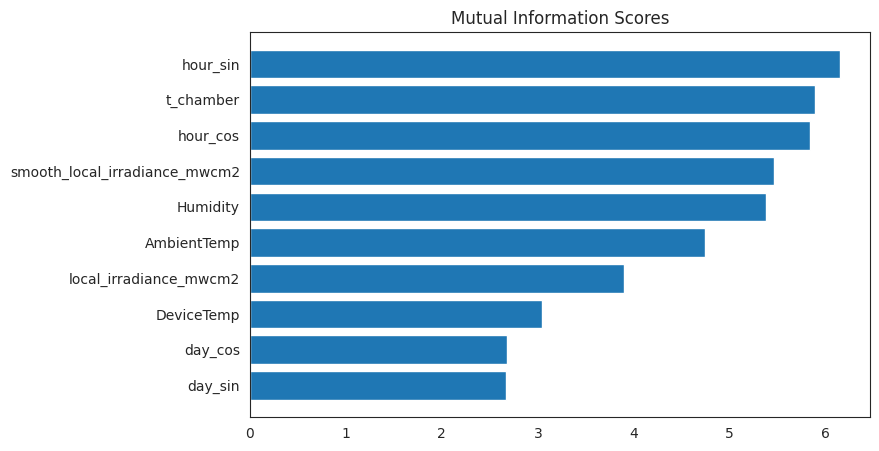

Train Dimensions: (749388, 7), Val Dimensions: (0, 7)

[VAL] --- Running GLOBAL Time Series Cross-Validation (Splits: 46) ---
 - Fold 01: MAE: 0.98 | RMSE: 1.84 | R2: 0.9859
 - Fold 02: MAE: 0.66 | RMSE: 0.76 | R2: 0.9982
 - Fold 03: MAE: 1.78 | RMSE: 3.93 | R2: 0.8572
 - Fold 04: MAE: 3.19 | RMSE: 3.23 | R2: 0.9591
 - Fold 05: MAE: 4.43 | RMSE: 7.88 | R2: 0.8028
 - Fold 06: MAE: 9.34 | RMSE: 11.68 | R2: 0.5620
 - Fold 07: MAE: 3.40 | RMSE: 3.96 | R2: 0.7690
 - Fold 08: MAE: 5.20 | RMSE: 5.35 | R2: 0.9485
 - Fold 09: MAE: 1.96 | RMSE: 2.19 | R2: 0.9851
 - Fold 10: MAE: 2.75 | RMSE: 3.16 | R2: 0.9689
 - Fold 11: MAE: 1.26 | RMSE: 1.95 | R2: 0.9893
 - Fold 12: MAE: 2.33 | RMSE: 2.56 | R2: 0.9805
 - Fold 13: MAE: 2.60 | RMSE: 3.10 | R2: 0.8850
 - Fold 14: MAE: 1.49 | RMSE: 1.84 | R2: 0.9926
 - Fold 15: MAE: 2.59 | RMSE: 3.05 | R2: 0.9751
 - Fold 16: MAE: 5.83 | RMSE: 7.27 | R2: 0.8633
 - Fold 17: MAE: 5.52 | RMSE: 7.91 | R2: 0.7529
 - Fold 18: MAE: 1.75 | RMSE: 2.35 | R2: 0.9854
 - Fold 1

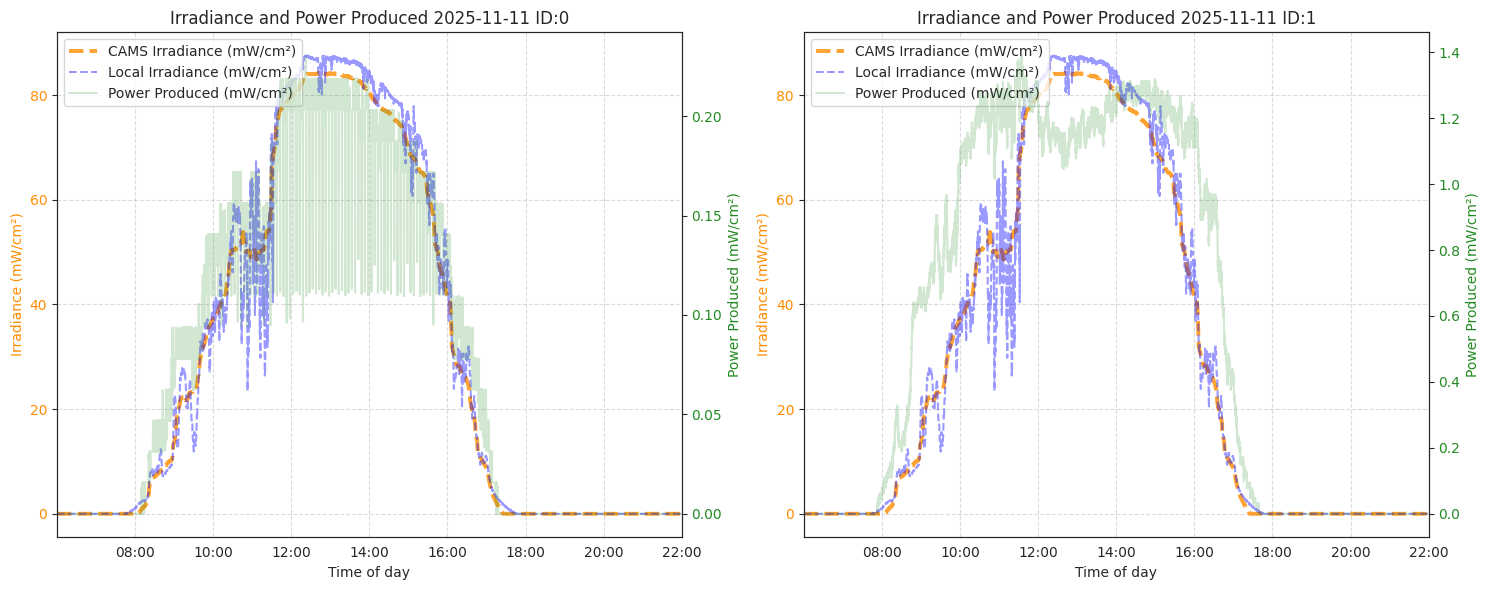

--- Imputation process finished ---


In [17]:
df = impute_cams_lr(train_day_split=50)

**Full visualization after Data Cleaning + Linear Regression**

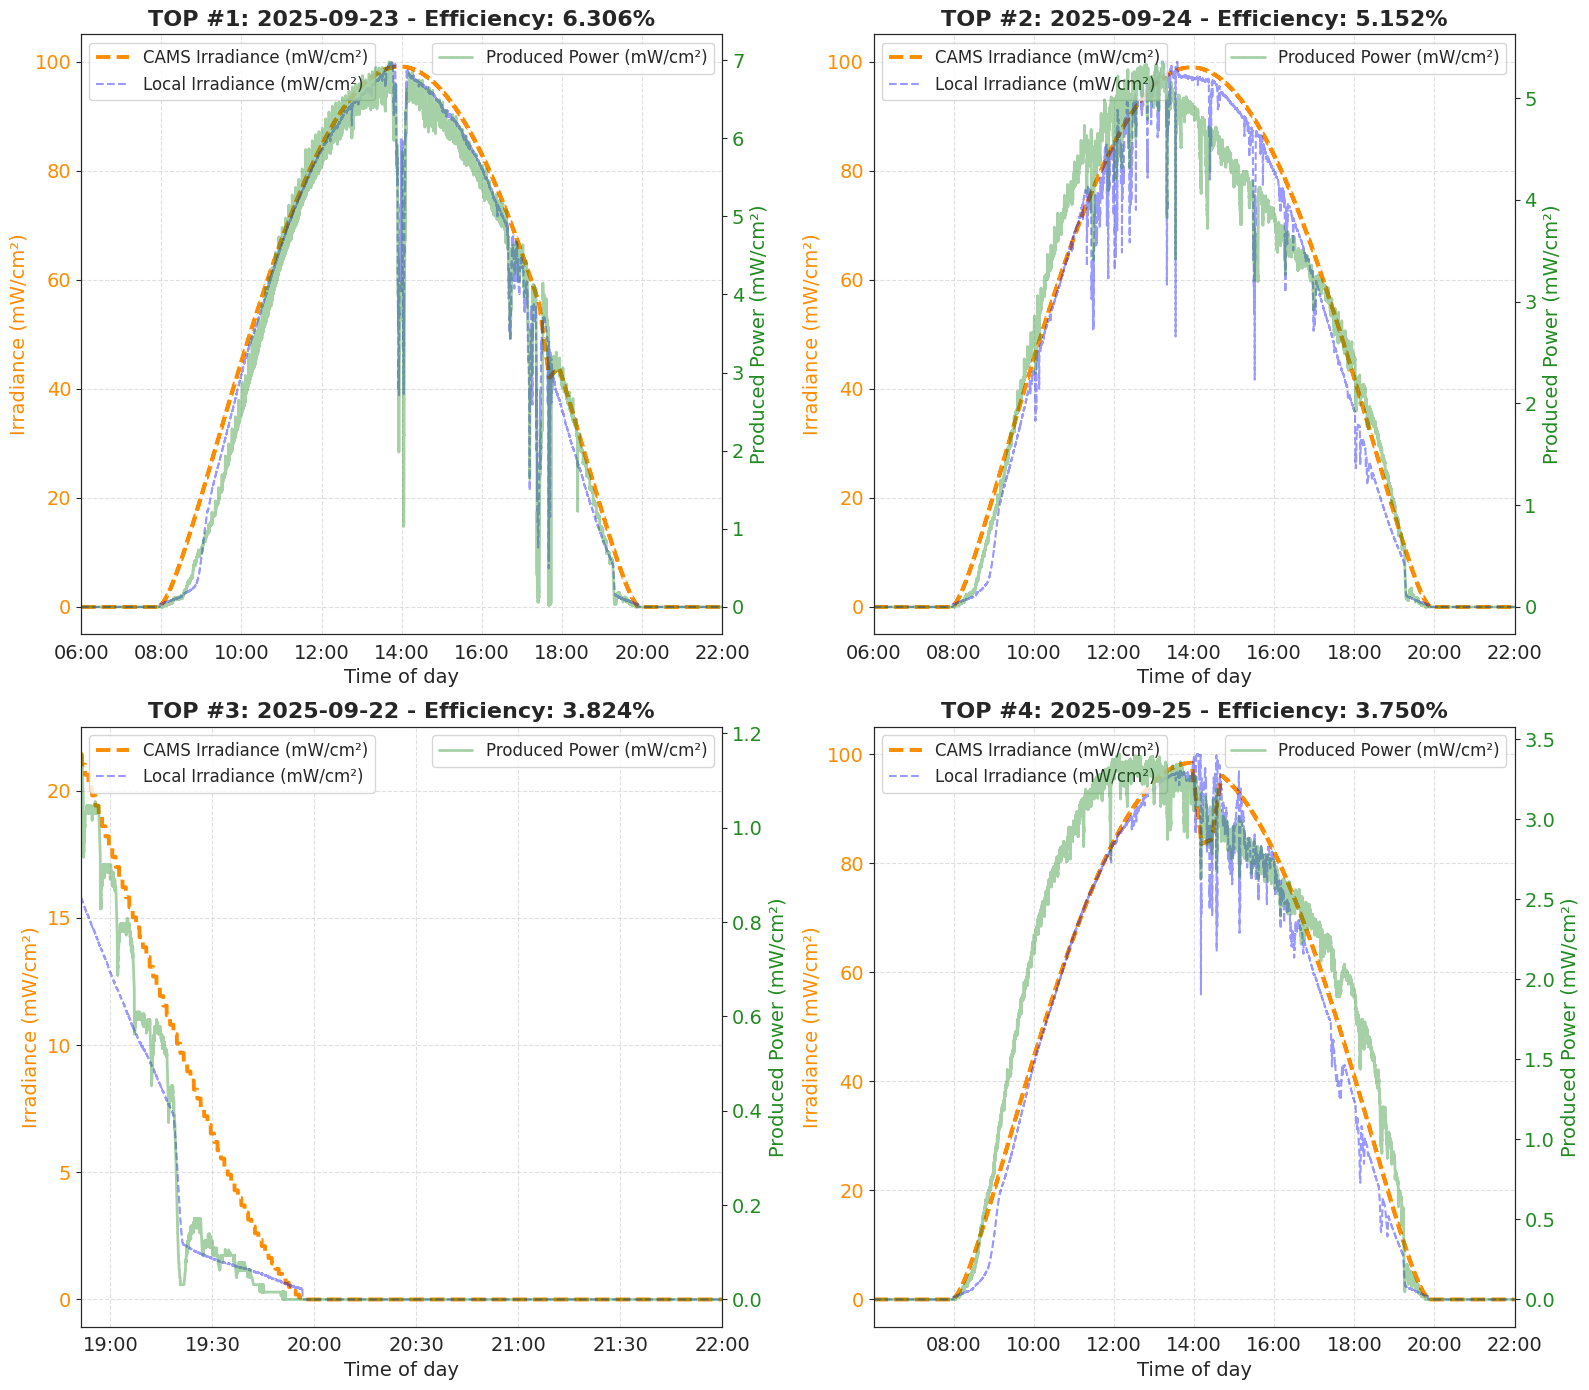

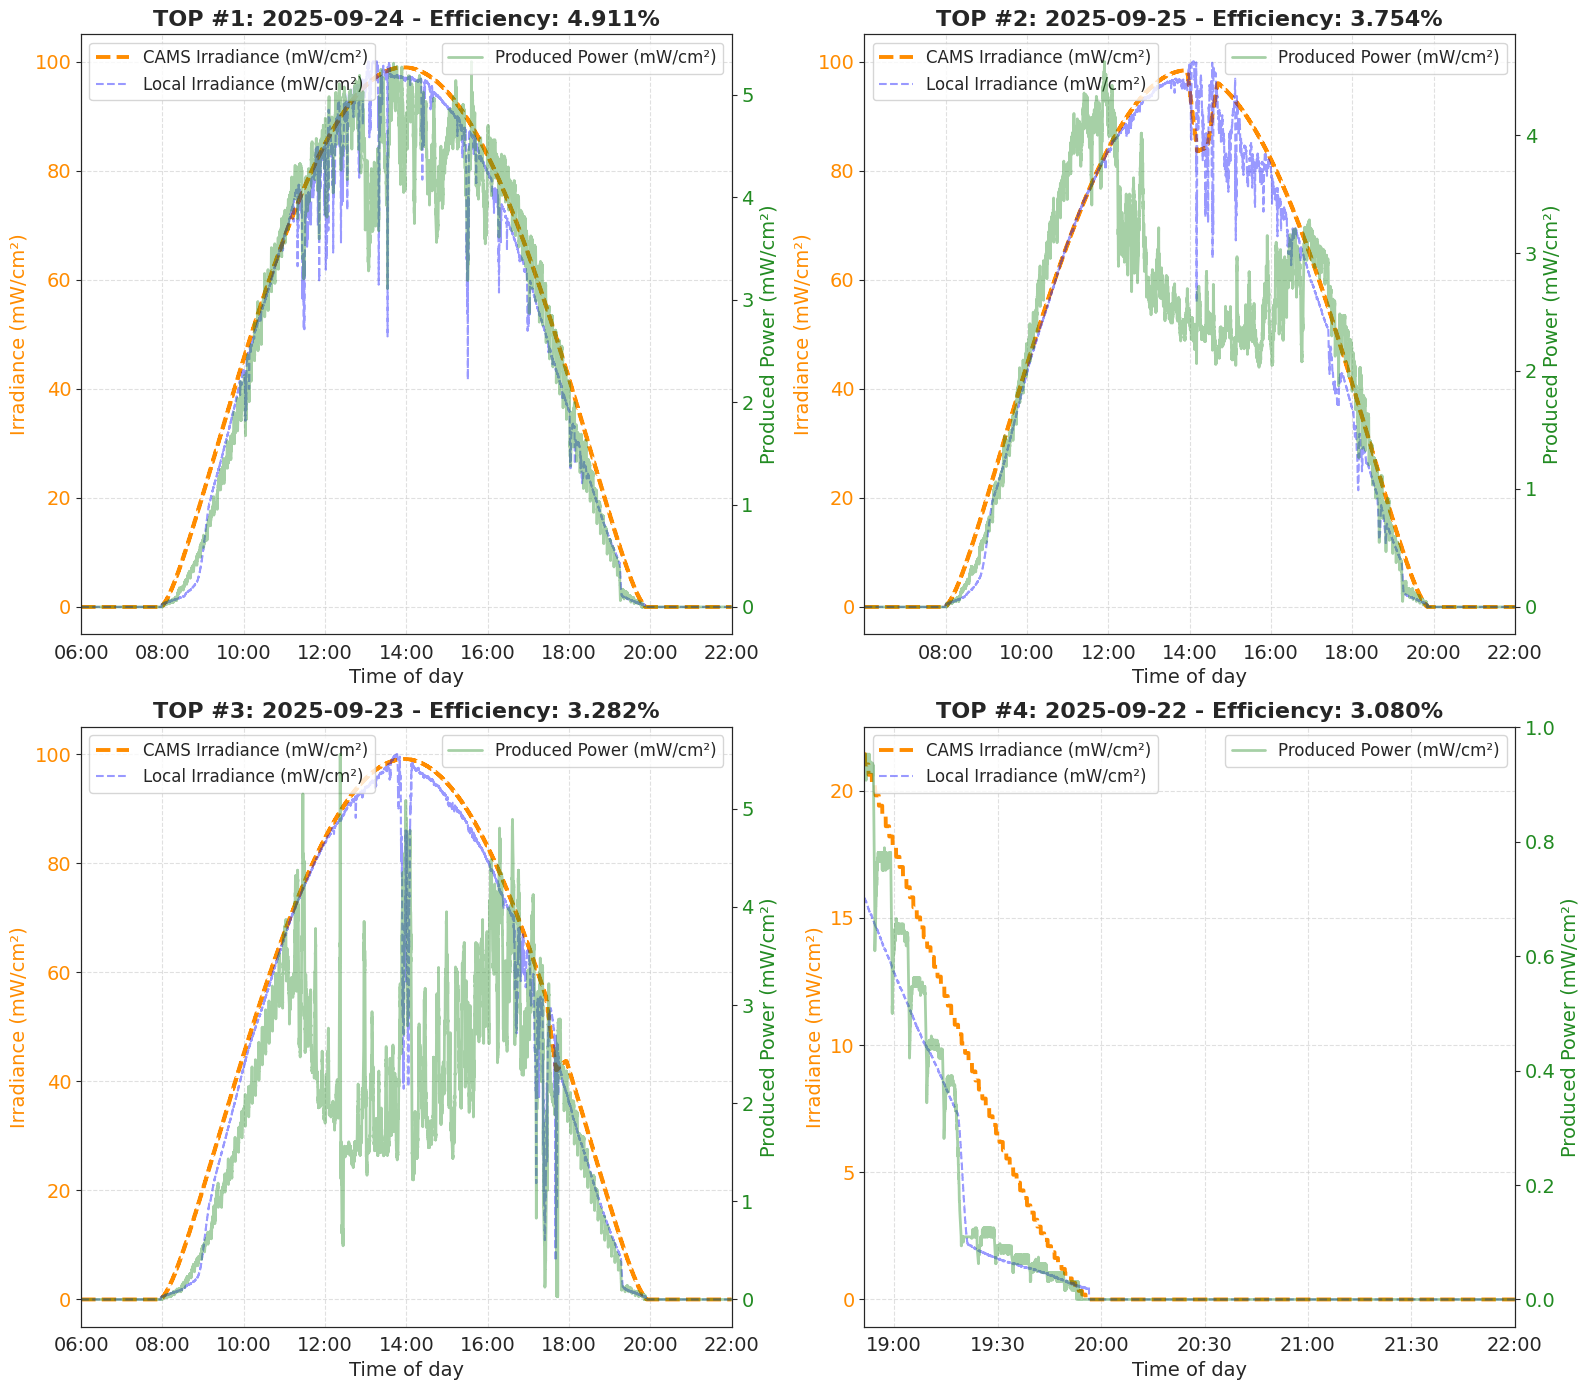

In [18]:
analyze_top4_by_cell(df_clean, cell_id=0)
print('\n')
analyze_top4_by_cell(df_clean, cell_id=1)

# **Integration of J-V Parameters (Health State)**

In [22]:
jv_params_wide = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/JV/jv_params_wide.parquet')

In [23]:
jv_params_wide

,index,id_curve,cell_id,label_curve,ff_fwd,ff_rev,jsc_fwd,jsc_rev,p_mpp_fwd,p_mpp_rev,time_fwd,time_rev,v_mpp_fwd,v_mpp_rev,voc_fwd,voc_rev,time_avg
0,0,1,0,0,0.318644,0.467210,4.618782,4.955645,1.076887,1.770396,2025-09-22 18:36:57.887849984,2025-09-22 18:36:45.555318016,378.26,485.52,732.548,742.336,2025-09-22 18:36:51.721584128
1,1,2,0,0,0.301464,0.475155,4.511007,4.511007,0.984776,1.644996,2025-09-22 18:41:58.308773888,2025-09-22 18:41:45.976614912,397.44,521.61,723.854,750.842,2025-09-22 18:41:52.142694400
2,2,3,0,0,0.316181,0.494997,3.951695,3.951409,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392
3,3,4,0,0,0.327281,0.513709,3.391087,3.390597,0.769996,1.298696,2025-09-22 18:51:59.142903040,2025-09-22 18:51:46.811891968,383.40,479.18,689.852,726.628,2025-09-22 18:51:52.977397504
4,4,5,0,0,0.299184,0.465992,3.394280,3.394280,0.686152,1.159819,2025-09-22 18:56:59.524162048,2025-09-22 18:56:47.193059072,371.92,493.55,676.998,721.136,2025-09-22 18:56:53.358610432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11359,11359,28531,1,2,0.294048,0.389994,1.138434,1.138434,0.192599,0.284018,2025-11-11 17:05:46.143228928,2025-11-11 17:05:33.819033088,350.35,455.43,560.112,633.472,2025-11-11 17:05:39.981131008
11360,11360,28532,1,2,0.441940,0.616564,0.569632,0.569632,0.127659,0.204509,2025-11-11 17:10:46.670853120,2025-11-11 17:10:34.352898048,300.08,431.55,496.538,578.350,2025-11-11 17:10:40.511875584
11361,11361,28533,1,2,0.419644,0.494728,0.569840,0.569840,0.107627,0.158727,2025-11-11 17:15:47.214900992,2025-11-11 17:15:34.895695872,288.74,417.54,457.388,554.244,2025-11-11 17:15:41.055298560
11362,11362,28534,1,2,0.345758,0.434548,0.570047,0.570047,0.081403,0.123325,2025-11-11 17:20:47.763085056,2025-11-11 17:20:35.437742080,274.73,381.40,396.376,504.616,2025-11-11 17:20:41.600413696


In [24]:
def merge_mpp_with_jv_params(df_mpp=df, jv_params_wide=jv_params_wide):
    print("--- Start: merge_mpp_with_jv_params ---")

    # --- MPP Preprocessing ---
    df = df_mpp.copy()
    if df.index.name is not None:
        df = df.reset_index()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time')

    print(f"MPP: {len(df)} rows. Time range: {df['time'].min()} - {df['time'].max()}")

    # --- JV Parameters Preprocessing ---
    params = jv_params_wide.copy()
    if params.index.name is not None:
        params = params.reset_index()
    params['time_avg'] = pd.to_datetime(params['time_avg'])
    params = params.sort_values('time_avg')

    print(f"JV: {len(params)} rows.")

    # Ensuring type consistency for the grouping key
    df['cell_id'] = df['cell_id'].astype(int)
    params['cell_id'] = params['cell_id'].astype(int)

    # Merge JV curve data to MPP (Strictly past data)
    # Using 'backward' ensures we only look at curves that happened at t_jv <= t_mpp
    print(f"\nRunning merge_asof (tolerance=15min, direction='backward')...")

    merged = pd.merge_asof(
        df,
        params,
        left_on='time',
        right_on='time_avg',
        by='cell_id', # Matches strictly by cell_id
        direction='backward', # CHANGED: respects causality (t_jv <= t_mpp)
        tolerance=pd.Timedelta('15min') # Look back up to 15 mins
    )

    # Check merge quality (how many MPP records found a JV curve)
    if 'id_curve' in merged.columns:
        matches = merged['id_curve'].notna().sum()
        print(f" Merge completed: {matches} records ({matches/len(merged):.1%}) found JV curve within tolerance.")

    # Filling 'Health State'
    # JV metrics (Voc, FF, Hysteresis) are state variables (slow).
    # Propagate them forward (ffill) until a new curve appears.

    print(" Filling health metrics (groupby cell_id + ffill)...")

    cols_health = [c for c in params.columns if c not in ['id_curve', 'cell_id']]
    # Note: We group by cell_id to prevent leaking data between cells
    merged[cols_health] = merged.groupby('cell_id')[cols_health].ffill()

    # Flagging (is_ffill)
    # Marking which data came directly from merge_asof and which is propagated

    print("Generating 'is_ffill' flag and cleaning NaNs in 'id_curve'...")
    # If id_curve is present (from merge), it's a direct match (0). If NaN, it's a fill (1).
    merged['is_ffill'] = merged['id_curve']
    merged.loc[merged['is_ffill'].notna(), 'is_ffill'] = 0
    merged.loc[merged['is_ffill'].isna(), 'is_ffill'] = 1
    merged['is_ffill'] = merged['is_ffill'].astype(int)

    # Fill id_curve nan with -1 to maintain type consistency (int)
    merged.loc[merged['id_curve'].isna(), 'id_curve'] = -1
    merged['id_curve'] = merged['id_curve'].astype(int)

    # Set time back as index and sort
    merged.set_index('time', inplace=True)
    merged = merged.sort_values(['cell_id', 'time'], ascending=[True, True])

    print(f"Final dimensions: {merged.shape}")
    print("--- End: merge_mpp_with_jv_params ---")

    return merged

In [25]:
df_clean = merge_mpp_with_jv_params()

--- Start: merge_mpp_with_jv_params ---
MPP: 5782604 rows. Time range: 2025-09-22 18:51:22 - 2025-11-11 22:00:00
JV: 11364 rows.

Running merge_asof (tolerance=15min, direction='backward')...
 Merge completed: 3558224 records (61.5%) found JV curve within tolerance.
 Filling health metrics (groupby cell_id + ffill)...
Generating 'is_ffill' flag and cleaning NaNs in 'id_curve'...
Final dimensions: (5782604, 33)
--- End: merge_mpp_with_jv_params ---


In [26]:
df_clean

,cell_id,power_cell_mwcm2,power_art,local_irradiance_mwcm2,local_irradiance_art,smooth_local_irradiance_mwcm2,hour_fraction,hour_sin,hour_cos,irradiance_30_degrees_mwcm2,...,p_mpp_fwd,p_mpp_rev,time_fwd,time_rev,v_mpp_fwd,v_mpp_rev,voc_fwd,voc_rev,time_avg,is_ffill
time,,,,,,,,,,,,,,,,,,,,,
2025-09-22 18:51:22,0,1.151306,0,15.782845,0,13.22283,18.841667,-0.975821,0.218569,21.441425,...,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392,0
2025-09-22 18:51:23,0,1.156250,0,15.782845,0,13.22283,18.841667,-0.975821,0.218569,21.441425,...,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392,0
2025-09-22 18:51:24,0,1.156250,0,15.782845,0,13.22283,18.841667,-0.975821,0.218569,21.441425,...,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392,0
2025-09-22 18:51:25,0,1.156216,0,15.735872,0,13.22283,18.841667,-0.975821,0.218569,21.441425,...,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392,0
2025-09-22 18:51:26,0,1.147543,0,15.735872,0,13.22283,18.841667,-0.975821,0.218569,21.441425,...,0.895287,1.511582,2025-09-22 18:46:58.690995968,2025-09-22 18:46:46.360899072,388.35,513.60,712.814,750.920,2025-09-22 18:46:52.525947392,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11 21:59:56,1,0.000000,0,0.000000,0,0.00000,21.991667,-0.501888,0.864933,0.000000,...,0.047567,0.082095,2025-11-11 17:25:48.304335104,2025-11-11 17:25:35.981272064,226.46,332.33,307.442,423.096,2025-11-11 17:25:42.142803456,1
2025-11-11 21:59:57,1,0.000000,0,0.000000,0,0.00000,21.991667,-0.501888,0.864933,0.000000,...,0.047567,0.082095,2025-11-11 17:25:48.304335104,2025-11-11 17:25:35.981272064,226.46,332.33,307.442,423.096,2025-11-11 17:25:42.142803456,1
2025-11-11 21:59:58,1,0.000000,0,0.000000,0,0.00000,21.991667,-0.501888,0.864933,0.000000,...,0.047567,0.082095,2025-11-11 17:25:48.304335104,2025-11-11 17:25:35.981272064,226.46,332.33,307.442,423.096,2025-11-11 17:25:42.142803456,1


We have real J-V curve data up to 11/11/2025 at 17:25, while the main DataFrame goes up to 22:00 on the same day.

Forward fill (ffill) was applied to all missing curves, assigning `id_curve=-1` and the flag `is_ffill=1` to these entries to identify them.

In [27]:
from google.colab import drive
import os

# Variable rename: ruta -> path
path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP'

# Create directory if it doesn't exist
if not os.path.exists(path):
    try:
        os.makedirs(path)
        print(f"Directory created: {path}")
    except OSError as e:
        print(f"Error creating directory. Check path. {e}")

# Save DataFrames
try:
    # IMPORTANT: If 'time' is in the index, index=False will remove it.
    # We use reset_index() temporarily to save the index as a column.

    # Option A: Save resetting index to avoid losing 'time' column
    df_clean.reset_index().to_parquet(f'{path}/df_clean.parquet', index=False)

    print("File saved successfully to Google Drive.")

except NameError as e:
    print(f"Error: Some variable is not defined. {e}")
except Exception as e:
    print(f"An unexpected error occurred while saving: {e}")

File saved successfully to Google Drive.


# **Full-cycle 24-hour data processing**

In [28]:
def process_mpp_meteo():
    print("--- Starting data processing (process_mpp_meteo) ---")

    # 1. Data loading
    print("Loading parquet files...")
    mpp_0 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/M0/MPP_interp.parquet')
    mpp_12 = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/P12/MPP_interp.parquet')
    cams = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/CAMS.parquet')
    meteo = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/TFG/data/METEO-2025-09-22_18_36_58--2025-11-11_22_01_04_calibrado23.4864.parquet')
    print("Files loaded.")

    # 2. Basic preprocessing
    mpp_0.set_index('time', inplace=True)
    mpp_12.set_index('time', inplace=True)

    # Round METEO to seconds to facilitate merging
    meteo.index = meteo.index.round('s')
    meteo.index.name = 'time'
    meteo = meteo.rename(columns={'Power' : 'local_irradiance_wm2'})

    # Manual warnings about known gaps
    print('\nMETEO: From 2025-10-05 22:00:56 jumps directly to 2025-10-05 23:00:01. (Data missing in that interval)')
    print('METEO: From 2025-10-06 22:00:59 jumps directly to 2025-10-06 23:00:00. (Data missing in that interval)')

    cams.set_index('time', inplace=True)
    cams.rename(columns={'irradiancia_30_grados':'irradiance_30_degrees'}, inplace=True)
    print('CAMS: Missing data for 11/11.')

    cams_30 = cams.loc[:, ['hour_fraction', 'irradiance_30_degrees']]
    cams_30 = cams_30.rename(columns={'irradiance_30_degrees': 'irradiance_30_degrees_wm2'})

    # 3. Aligning METEO with CAMS (Backward)
    print("\nAligning METEO with CAMS...")
    cams_30 = cams_30.sort_index()
    # Changed to direction='backward'
    df_meteo_cams = pd.merge_asof(meteo['local_irradiance_wm2'], cams_30, on='time', direction='backward', tolerance=pd.Timedelta('60s'))

    df_meteo_cams_clean = df_meteo_cams.copy()

    print(f"NaN in df_meteo_cams_clean (before imputation):\n{df_meteo_cams_clean.isnull().sum()}")
    print('CAMS has missing values (NaN) due to the cutoff time difference (00:59:30 in CAMS vs 21:59:57 in METEO on 11/11)')
    null_percentage = df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams_clean) * 100
    print(f"Global null percentage: {null_percentage:.2f}%")
    print(f'NaNs correspond to  ∼{round(null_percentage)}%  of total data')

    # 4. Imputation of CAMS irradiance using METEO
    print("\nImputation of missing CAMS values:")
    print("\nImputing missing CAMS irradiance with METEO data (temporarily)...")
    df_meteo_cams_clean['irradiance_30_is_imputed'] = (df_meteo_cams_clean['irradiance_30_degrees_wm2'].isnull() == True).astype(int)
    df_meteo_cams_clean['irradiance_30_degrees_wm2'] = df_meteo_cams_clean['irradiance_30_degrees_wm2'].fillna(df_meteo_cams_clean['local_irradiance_wm2'])

    print(f"NaN percentage after irradiance imputation: {df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams) * 100:.2f}%")

    # 5. Imputation of 'hour_fraction'
    # A reference day (2025-09-27) is used to fill gaps of hour_fraction in other days
    print("\nImputing missing CAMS 'hour_fraction' using pattern day 2025-09-27 (example)...")
    df_meteo_cams_clean.set_index('time', inplace=True)
    hour_fraction_input = df_meteo_cams_clean[df_meteo_cams_clean.index.date == pd.to_datetime('2025-09-27').date()]['hour_fraction']
    df_meteo_cams_nan = df_meteo_cams_clean[df_meteo_cams_clean['hour_fraction'].isnull()]['hour_fraction']

    df_meteo_cams_nan = df_meteo_cams_nan.to_frame()
    df_meteo_cams_nan.reset_index(inplace=True)
    df_meteo_cams_nan = df_meteo_cams_nan.drop('time', axis=1)
    df_meteo_cams_nan = df_meteo_cams_nan.fillna(0)

    hour_fraction_input = hour_fraction_input.to_frame()
    hour_fraction_input.reset_index(inplace=True)
    hour_fraction_input = hour_fraction_input.drop('time', axis=1)

    df_meteo_cams_nan = df_meteo_cams_nan.sort_index()
    hour_fraction_input = hour_fraction_input.sort_index()

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(df_meteo_cams_nan, hour_fraction_input, left_index=True, right_index=True, direction='backward', tolerance=2)
    df_input = df_align_0.copy()['hour_fraction_y']
    df_meteo_cams_clean.loc[df_meteo_cams_clean['hour_fraction'].isnull(), 'hour_fraction'] = df_input.values

    print(f'Final NaNs after imputing hour_fraction: {df_meteo_cams_clean.isnull().sum().sum() / len(df_meteo_cams) * 100:.4f}%')

    # 6. Alignment of MPP with METEO & CAMS
    print("\nAligning MPP data with CAMS dataset...")
    # Remove nights in MPP
    mpp_clean_0 = mpp_0.copy()
    mpp_clean_12 = mpp_12.copy()

    # Alignment MPP with CAMS
    df_meteo_cams_clean = df_meteo_cams_clean.sort_index()

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(mpp_clean_0, df_meteo_cams_clean, on='time', direction='backward', tolerance=pd.Timedelta('4s'))
    df_align_12 = pd.merge_asof(mpp_clean_12, df_meteo_cams_clean, on='time', direction='backward', tolerance=pd.Timedelta('4s'))

    # 7. Post-alignment cleaning (24h)
    print('\nPost-alignment cleaning (preserving nights)...')

    df_align_0['irradiance_30_degrees_wm2'] = df_align_0['irradiance_30_degrees_wm2'].fillna(0)
    df_align_12['irradiance_30_degrees_wm2'] = df_align_12['irradiance_30_degrees_wm2'].fillna(0)

    df_align_0 = df_align_0.dropna(subset=['local_irradiance_wm2', 'Humidity'])
    df_align_12 = df_align_12.dropna(subset=['local_irradiance_wm2', 'Humidity'])

    before_dropna = len(df_align_12)
    df_align_12 = df_align_12.dropna()
    print(f"P12 rows cleaned after dropna: {before_dropna - len(df_align_12)}")
    df_align_12 = df_align_12.reset_index()

    # 8. Adding extra environmental variables (METEO)
    print("\nAdding METEO environmental variables (Temp, Humidity)...")

    # Changed to direction='backward'
    df_align_0 = pd.merge_asof(df_align_0, meteo[['DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity' ]], on='time', direction='backward', tolerance=pd.Timedelta('4s'))
    df_align_12 = pd.merge_asof(df_align_12, meteo[['DeviceTemp', 't_chamber', 'AmbientTemp', 'Humidity' ]], on='time', direction='backward', tolerance=pd.Timedelta('4s'))

    print(f'NaN found in final M0: {df_align_0.isnull().sum().sum()}')
    print(f'inf found in final M0: {(len(df_align_0) - np.isfinite(df_align_0).sum()).sum()}')
    print(f'NaN found in final P12: {df_align_12.isnull().sum().sum()}')
    print(f'inf found in final P12: {(len(df_align_12) - np.isfinite(df_align_12).sum()).sum()}')

    # 9. Vertical merge and unit conversion
    print("\nJoining M0 and P12 datasets and converting units...")
    df_align_0.insert(loc=1, column='cell_id', value=0) # Label M0
    df_align_12.insert(loc=1, column='cell_id', value=1) # Label P12
    df_align = pd.concat([df_align_0, df_align_12], axis=0, ignore_index=True)

    # Conversion W/m2 to mW/cm2 (Factor: * 0.1)
    df_align['local_irradiance_wm2'] = df_align['local_irradiance_wm2'] * 1000 / 10000
    df_align = df_align.rename(columns={'local_irradiance_wm2' : 'local_irradiance_mwcm2'})

    df_align['irradiance_30_degrees_wm2'] = df_align['irradiance_30_degrees_wm2'] * 1000 / 10000
    df_align = df_align.rename(columns={'irradiance_30_degrees_wm2' : 'irradiance_30_degrees_mwcm2'})
    df_align = df_align.rename(columns={'power' : 'power_cell_mwcm2'})
    df_align['irradiance_30_is_imputed'] = df_align['irradiance_30_is_imputed'].astype(int)

    if df_align.index.name == None:
        df_align.set_index('time', inplace=True)

    print(f"--- Process finished. Final dimensions: {df_align.shape} ---")
    return df_align

df_full = data_clean(df_align)

--- Starting data cleaning (data_clean) ---

Power Artifacts detected: 46266
Setting 'power_cell_mwcm2' to 0 in those records...

Local Irradiance Artifacts detected: 92472
Setting 'local_irradiance_mwcm2' to 0 in those records...

Over-Irradiance (Local > 100) detected: 23894
Clipping 'local_irradiance_mwcm2' maximum values to 100.0...
Over-Irradiance (CAMS > 100) detected: 0

--- Cleaning finished ---


In [29]:
from google.colab import drive
import os

path = '/content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP'

if not os.path.exists(path):
    os.makedirs(path)
    print(f"Directorio creado: {path}")

try:
    df_full.reset_index().to_parquet(f'{path}/df_full.parquet', index=False)
except Exception as e:
    print(f"Error al guardar: {e}")

Archivo 'df_full.parquet' guardado con éxito en: /content/drive/MyDrive/Colab Notebooks/TFG/Datasets/MPP
